# CellPert — End-to-End Tutorial

This notebook walks through a full CellPert use case from a clean checkout:

1. **Environment & data setup** — install dependencies and pull the LINCS / Tahoe datasets and pretrained weights from HuggingFace.
2. **Load the pretrained GINVAE model.**
3. **Build the reference biological context** from LINCS (control vs. perturb latent centroids).
4. **Predict perturbation responses** on a Tahoe query plate.
5. **Evaluate** the prediction (Pearson / Spearman / DEG-delta) on paired control–perturb samples.
All paths are relative to the repo root (`CellPert/`). After downloading the data the layout should look like:

```
CellPert/
├── src/
│   └── best_gin_vae_model_node_level.pth
├── data/
│   ├── lincs/merged_all_965_with_morgan.h5ad
│   └── minitahoe/p1_with_morgan.h5ad ... p14_with_morgan.h5ad
```

## 1. Environment & data

Run these once in a shell — *not* inside the notebook unless you want to (un)comment the `!`-prefixed lines.

```bash
conda env create -f environment.yml
conda activate info
```

Then download the model weights and datasets from HuggingFace (the repo is public, no token needed):

In [1]:
# One-time download. Everything here is skipped when the files are already in place,
# so the cell is safe to re-run.
import os
import tarfile
import zipfile

REPO_ID = 'Mike2481/CellPert'
CKPT = './src/best_gin_vae_model_node_level.pth'
LINCS_H5AD = './data/lincs/merged_all_965_with_morgan.h5ad'
TAHOE_H5AD = './data/minitahoe/p1_with_morgan.h5ad'

os.makedirs('./data', exist_ok=True)
need = [p for p in (CKPT, LINCS_H5AD, TAHOE_H5AD) if not os.path.exists(p)]
if not need:
    print('checkpoint and data already present, nothing to download')
else:
    from huggingface_hub import hf_hub_download

    if not os.path.exists(CKPT):
        hf_hub_download(repo_id=REPO_ID, filename='best_gin_vae_model_node_level.pth',
                        repo_type='dataset', local_dir='./src')

    if not os.path.exists(LINCS_H5AD):
        lincs_zip = hf_hub_download(repo_id=REPO_ID, filename='lincs.zip',
                                    repo_type='dataset', local_dir='./data')
        with zipfile.ZipFile(lincs_zip) as z:
            z.extractall('./data/')

    if not os.path.exists(TAHOE_H5AD):
        tahoe_tar = hf_hub_download(repo_id=REPO_ID, filename='minitahoe.tar.gz',
                                    repo_type='dataset', local_dir='./data')
        with tarfile.open(tahoe_tar, 'r:gz') as t:
            t.extractall('./data/')
    print('downloaded:', ', '.join(need))


checkpoint and data already present, nothing to download


## 2. Load the pretrained GINVAE

`GINVAE` defaults: `input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2`. Match these to the checkpoint.

In [2]:
import sys
sys.path.insert(0, './src')

import torch
from model import GINVAE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load('./src/best_gin_vae_model_node_level.pth', map_location=device))
model.eval();

## 3. Build the reference biological context

CellPert transfers a perturbation effect from a *reference* dataset (LINCS) to a *query* dataset (Tahoe). The reference contributes two centroids in latent space:

$$z^{\text{perturb}}_{\text{query}} = z^{\text{ctrl}}_{\text{query}} + (\bar z^{\text{perturb}}_{\text{ref}} - \bar z^{\text{ctrl}}_{\text{ref}})$$

The first call processes LINCS and caches `latent_ctrl_ref` / `latent_ptrb_ref` to disk; subsequent calls are instant.

In [3]:
from dataset import ChunkedGeneGraphDataset
import os

os.makedirs('./output', exist_ok=True)

lincs_path = './data/lincs/merged_all_965_with_morgan.h5ad'
lincs_dataset = ChunkedGeneGraphDataset(
    h5ad_paths=[lincs_path], split='train',
    chunk_size=10000, auto_build_graph=True,
    species=9606, required_score=700,
)

latent_ctrl_ref, latent_ptrb_ref, info = model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path='./output/reference_latents.pkl',
    force_reprocess=False,
)
print('ctrl latent shape :', latent_ctrl_ref.shape)
print('perturb latent shape:', latent_ptrb_ref.shape)

Found 16 chunks with 157138 total samples
Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks:   0%|          | 0/16 [00:00<?, ?it/s]

Loading chunks:   0%|          | 0/16 [00:00<?, ?it/s, file=chunk_0.pkl]

Loading chunks:   0%|          | 0/16 [00:00<?, ?it/s, file=chunk_1.pkl]

Loading chunks:   0%|          | 0/16 [00:00<?, ?it/s, file=chunk_2.pkl]

...

Processing perturb samples:  79%|███████▉  | 61985/78569 [00:00<00:00, 62447.06it/s]

Processing perturb samples:  90%|█████████ | 70855/78569 [00:01<00:00, 68980.88it/s]

Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 68766.27it/s]

Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 2.2677
perturb ref shape: torch.Size([1, 100]), norm: 2.2584
Biological context norm: 0.0157


ctrl latent shape : torch.Size([1, 100])
perturb latent shape: torch.Size([1, 100])


## 4. Predict perturbation responses on a query plate

In [4]:
from torch_geometric.data import DataLoader

tahoe_path = './data/minitahoe/p1_with_morgan.h5ad'
tahoe_dataset = ChunkedGeneGraphDataset(
    h5ad_paths=[tahoe_path], split='test',
    chunk_size=10000, auto_build_graph=True,
    species=9606, required_score=700,
)

loader = DataLoader(tahoe_dataset, batch_size=64, shuffle=False)
batch = next(iter(loader)).to(device)
predicted_exp, mask = model.predict(batch, latent_ctrl_ref, latent_ptrb_ref)
print('predicted expression shape:', predicted_exp.shape)

Found 4 chunks with 39546 total samples


predicted expression shape: torch.Size([64, 965, 1])


## 5. Evaluate on paired control–perturb samples

Re-uses the same evaluation pipeline that `src/main.py` runs in `--test_flag` mode:

* Filters Tahoe by `condition ∈ {control, perturb}`.
* Pairs them on `(celltype, main_ptrb, sub_ptrb)`.
* Computes per-sample Pearson / Spearman on absolute expression and on the DEG delta `pred − ctrl`.

Two equivalent ways to run it:

In [5]:
# Option A — call the helper directly from main.py
import argparse
from main import evaluate_perturbation_prediction

args = argparse.Namespace(
    device=device, batch_size=64,
    output_dir='./output', test_dataset_id=1,
)
results = evaluate_perturbation_prediction(
    model, tahoe_dataset, latent_ctrl_ref, latent_ptrb_ref,
    args, max_test_pairs=200, compute_deg=True,
)
print('absolute :', results['absolute_metrics'])
print('DEG delta:', results['deg_metrics'])

Filtering test dataset by condition...
Filtering dataset for condition: control


Filtering control samples:   0%|          | 0/39546 [00:00<?, ?it/s]

Filtering control samples:  25%|██▌       | 10001/39546 [00:00<00:01, 22641.47it/s]

Filtering control samples:  51%|█████     | 20001/39546 [00:00<00:00, 21179.94it/s]

Filtering control samples:  76%|███████▌  | 30001/39546 [00:01<00:00, 20106.41it/s]

...

Predicting perturbations:  50%|█████     | 2/4 [00:00<00:00, 12.24it/s]

Predicting perturbations: 100%|██████████| 4/4 [00:00<00:00, 15.79it/s]

Processing prediction results...
Processed 200 prediction pairs



Perturbation Prediction Metrics (Control → Predicted Stimulated vs Ground Truth Stimulated):
MSE                  39.988014
MAE                   6.311637
R2                 -405.085305
Pearson               0.339594
Spearman              0.149551
CosineSimilarity      0.411635
JS_Divergence         0.309499
SSIM                  0.011600
TopK_Overlap          0.010200
total_samples       200.000000
dtype: float64

Computing DEG (delta difference) metrics...

DEG Prediction Metrics (Predicted Delta vs Ground Truth Delta):
MSE                   39.988468
MAE                    6.311716
R2                 -1044.848230
Pearson                0.224231
Spearman               0.199685
CosineSimilarity       0.014330
JS_Divergence          0.003801
SSIM                  -0.003112
TopK_Overlap           0.063450
total_samples        200.000000
dtype: float64

✓ Results appended to: ./output/all_plates_results.csv
✓ Predictions saved to: ./output/predictions/plate_1_predictions.pkl
✓ Single pl

absolute : {'MSE': 39.98801359176636, 'MAE': 6.311636955738067, 'R2': -405.0853049278259, 'Pearson': 0.33959356097504495, 'Spearman': 0.1495512298263202, 'CosineSimilarity': 0.4116351864486933, 'JS_Divergence': 0.3094987535476685, 'SSIM': 0.01160015142726479, 'TopK_Overlap': 0.0102, 'total_samples': 200}
DEG delta: {'MSE': 39.98846828460693, 'MAE': 6.31171569108963, 'R2': -1044.8482299423217, 'Pearson': 0.22423133999109268, 'Spearman': 0.19968534130835905, 'CosineSimilarity': 0.01433025841914059, 'JS_Divergence': 0.0038007948276208483, 'SSIM': -0.003112123163616616, 'TopK_Overlap': 0.06345, 'total_samples': 200}


In [6]:
# Option B — full sweep from the shell (one CSV row per plate)
# bash src/run_all.sh
# After it finishes, results land in:
#   output/all_plates_results.csv
#   output/predictions/plate_*_predictions.pkl

## 6. Put predictions on a common output scale

CellPert is trained on LINCS L1000 and evaluated on Mini Tahoe, and the two are on
different output scales: the LINCS training matrix has mean 8.43, the Mini Tahoe
targets have mean 0.14. Metrics react to that gap very differently. Pearson and
Spearman are invariant to any positive affine transformation of the prediction, so
they are unaffected. Mean squared error, R^2, cosine similarity and SSIM are not
invariant, and on raw output they largely measure the scale gap rather than the
prediction.

The diagnostic below removes the gap without touching the model. One scalar pair
`(a, b)` is fitted by least squares on a single plate,

```
a = Cov(P, G) / Var(P)      b = mean(G) - a * mean(P)
```

and then frozen and applied unchanged to every other plate, as `a * P + b`. It has
two degrees of freedom in total, so it cannot encode anything perturbation-specific;
it only places the output on the target scale.

Two things are worth checking whenever this is used. Pearson and Spearman must come
out identical before and after, which is a correctness check on the implementation.
And the fitted `a` must be reported: if `a` is near zero the calibrated prediction
collapses to the constant `b`, which equals the mean of the ground truth, and every
error-based metric then describes the ground truth alone rather than the model. On
the released checkpoint the fit gives `a = 0.657512` and `b = -4.083115`, and over
the held-out plates the metrics move as follows.

| metric | raw | calibrated |
| --- | --- | --- |
| Pearson | 0.3868 | 0.3868 |
| Spearman | 0.1380 | 0.1380 |
| MSE | 40.9121 | 0.1142 |
| R^2 | -555.63 | -0.0963 |
| Cosine similarity | 0.3825 | 0.4967 |
| SSIM | 0.0117 | 0.1934 |


In [7]:
import pickle
import numpy as np

# Predictions written by src/main.py in --test_flag mode, or by src/run_all.sh.
with open('./output/predictions/plate_1_predictions.pkl', 'rb') as f:
    d = pickle.load(f)
P = np.asarray(d['predictions'], dtype=np.float64)    # cells x 965
G = np.asarray(d['ground_truth'], dtype=np.float64)

# Fit the two scalars on this plate, then treat them as fixed.
p, g = P.ravel(), G.ravel()
a = float(np.cov(p, g, bias=True)[0, 1] / p.var())
b = float(g.mean() - a * p.mean())
print('fitted on plate 1:  a = %.6f   b = %.6f' % (a, b))
if abs(a) < 1e-3:
    print('warning: a is near zero, the calibrated output is essentially the constant b')

Q = a * P + b        # apply to this plate, and to every other plate unchanged


def report(name, X):
    xc = X - X.mean(1, keepdims=True)
    gc = G - G.mean(1, keepdims=True)
    den = np.linalg.norm(xc, axis=1) * np.linalg.norm(gc, axis=1)
    pearson = np.nanmean(np.where(den > 0, (xc * gc).sum(1) / np.maximum(den, 1e-12), np.nan))
    cosine = np.nanmean((X * G).sum(1) /
                        (np.linalg.norm(X, axis=1) * np.linalg.norm(G, axis=1) + 1e-12))
    mse = float(((X - G) ** 2).mean())
    r2 = float(1 - ((X - G) ** 2).sum() / ((G - G.mean()) ** 2).sum())
    print('%-12s MSE %10.4f   R2 %10.4f   Pearson %.4f   cosine %.4f'
          % (name, mse, r2, pearson, cosine))


report('raw', P)
report('calibrated', Q)

# Pearson is identical on both lines. That is the point: the affine changes the scale
# of the output and nothing about the ordering or the shape of what the model predicts.


fitted on plate 1:  a = 0.579841   b = -3.586739
raw          MSE    39.9880   R2  -228.7023   Pearson 0.3396   cosine 0.4116
calibrated   MSE     0.1651   R2     0.0517   Pearson 0.3396   cosine 0.5021


## 7. Alignment versus collapse in the latent space

Both analyses below rest on one object, the encoder's graph-level mean `graph_mu`. The
first measures how far apart the two datasets sit before and after the encoder, plate by
plate. The second draws the same two spaces with UMAP.

`umap-learn` is needed for the last cell and is not part of `environment.yml`; install
it with `pip install umap-learn` if it is missing.


In [8]:
import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader

# Sizes kept modest so the section runs in a few minutes. The published analysis used
# 15000 LINCS cells and 2500 from each plate.
N_LINCS, N_PER_PLATE, BATCH = 1500, 800, 256

# One graph, shared by every plate. All plates carry the same 965 genes and the same
# STRING edges, so the graph is built once and reused rather than rebuilt per plate.
EDGE_INDEX = tahoe_dataset[0].edge_index


def encode(X):
    """Encoder graph-level mean for a matrix of cells by genes."""
    out = []
    model.eval()
    with torch.no_grad():
        for s in range(0, len(X), BATCH):
            chunk = [Data(x=torch.tensor(X[i], dtype=torch.float).unsqueeze(1),
                          edge_index=EDGE_INDEX) for i in range(s, min(s + BATCH, len(X)))]
            b = next(iter(GeoLoader(chunk, batch_size=len(chunk), shuffle=False))).to(device)
            _, _, gmu, _ = model.encoder(b.x, b.edge_index, b.batch)
            out.append(gmu.cpu().numpy())
    return np.concatenate(out).astype(np.float32)


import scanpy as sc

to_dense = lambda X: np.asarray(X.todense() if hasattr(X, 'todense') else X, dtype=np.float32)


def sample(path, n, seed):
    ad = sc.read_h5ad(path)
    r = np.random.default_rng(seed)
    idx = r.choice(ad.n_obs, size=min(n, ad.n_obs), replace=False)
    return to_dense(ad.X)[idx], ad.obs.iloc[idx]


LX, _ = sample(lincs_path, N_LINCS, 0)
LZ = encode(LX)
print('LINCS  raw', LX.shape, ' latent', LZ.shape)


LINCS  raw (1500, 965)  latent (1500, 100)


### 7a. Dataset separability, plate by plate

Two statistics, each computed once in the raw 965-gene space and once in the
100-dimensional latent space, for every Mini Tahoe plate against the same LINCS sample.

* **KS statistic**, the two-sample Kolmogorov-Smirnov statistic between the two datasets,
  computed per dimension and averaged over dimensions.
* **Silhouette score** with `metric='cosine'`, labelling each cell by its dataset.

Lower means the two datasets sit closer together. For reference, the published run gives
means over the fourteen plates of 0.9996 in raw space against 0.9800 in the latent for
KS, and 0.9335 against 0.9134 for silhouette.


P1   KS 0.9987 -> 0.6825   silhouette 0.7683 -> 0.5175


P2   KS 0.9994 -> 0.7819   silhouette 0.8570 -> 0.7362


P3   KS 0.9997 -> 0.8453   silhouette 0.8112 -> 0.8491


P4   KS 0.9993 -> 0.7695   silhouette 0.8932 -> 0.7079


P5   KS 0.9997 -> 0.8759   silhouette 0.8114 -> 0.8769


...

P10  KS 0.9998 -> 0.9034   silhouette 0.8597 -> 0.9065


P11  KS 0.9991 -> 0.8164   silhouette 0.9001 -> 0.8004


P12  KS 0.9994 -> 0.8596   silhouette 0.8506 -> 0.8745


P13  KS 0.9995 -> 0.8693   silhouette 0.8385 -> 0.8846


P14  KS 0.9997 -> 0.8769   silhouette 0.8174 -> 0.8770


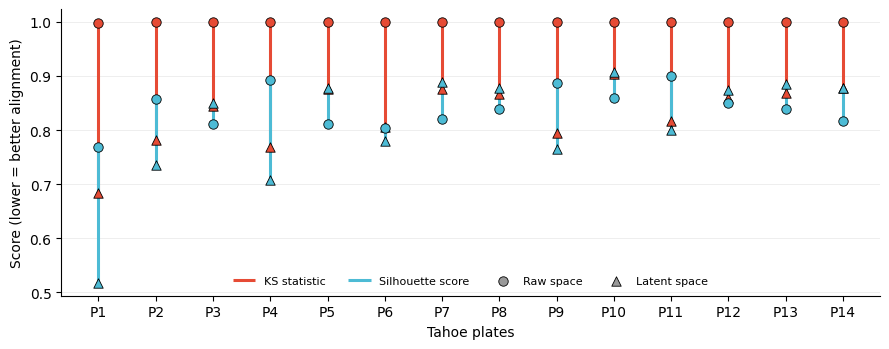

In [9]:
from scipy.stats import ks_2samp
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


def ks_mean(A, B):
    """Mean over dimensions of the two-sample KS statistic."""
    return float(np.mean([ks_2samp(A[:, j], B[:, j])[0] for j in range(A.shape[1])]))


def sil(A, B, n=2400, seed=0):
    M = np.concatenate([A, B])
    lab = np.array(['LINCS'] * len(A) + ['Tahoe'] * len(B))
    r = np.random.default_rng(seed)
    i = r.choice(len(M), size=min(n, len(M)), replace=False)
    return float(silhouette_score(M[i], lab[i], metric='cosine'))


rows = []
for p in range(1, 15):
    TX_p, _ = sample('./data/minitahoe/p%d_with_morgan.h5ad' % p, N_PER_PLATE, p)
    TZ_p = encode(TX_p)
    rows.append({'plate': p,
                 'ks_raw': ks_mean(LX, TX_p), 'ks_latent': ks_mean(LZ, TZ_p),
                 'sil_raw': sil(LX, TX_p), 'sil_latent': sil(LZ, TZ_p)})
    print('P%-2d  KS %.4f -> %.4f   silhouette %.4f -> %.4f'
          % (p, rows[-1]['ks_raw'], rows[-1]['ks_latent'],
             rows[-1]['sil_raw'], rows[-1]['sil_latent']), flush=True)

x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(9, 3.6))
for key_raw, key_lat, color, name in (('ks_raw', 'ks_latent', '#E64B35', 'KS statistic'),
                                      ('sil_raw', 'sil_latent', '#4DBBD5', 'Silhouette score')):
    hi = np.array([r[key_raw] for r in rows])
    lo = np.array([r[key_lat] for r in rows])
    ax.vlines(x, lo, hi, color=color, lw=2.2, zorder=1, label=name)
    ax.scatter(x, hi, s=46, facecolor=color, edgecolor='black', lw=0.6, zorder=2)
    ax.scatter(x, lo, s=46, marker='^', facecolor=color, edgecolor='black', lw=0.6, zorder=2)
ax.scatter([], [], s=46, facecolor='0.6', edgecolor='black', lw=0.6, label='Raw space')
ax.scatter([], [], s=46, marker='^', facecolor='0.6', edgecolor='black', lw=0.6,
           label='Latent space')
ax.set_xticks(x); ax.set_xticklabels(['P%d' % r['plate'] for r in rows])
ax.set_xlabel('Tahoe plates')
ax.set_ylabel('Score (lower = better alignment)')
ax.legend(frameon=False, ncol=4, fontsize=8, loc='lower center')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, lw=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


### 7b. The same two spaces drawn with UMAP

The top row is the raw 965-gene space and the bottom row the latent space, each coloured
three ways: by dataset, by Mini Tahoe cell line, and by perturbation state. LINCS is drawn
in grey in the second and third columns so the Mini Tahoe structure can be read against it.


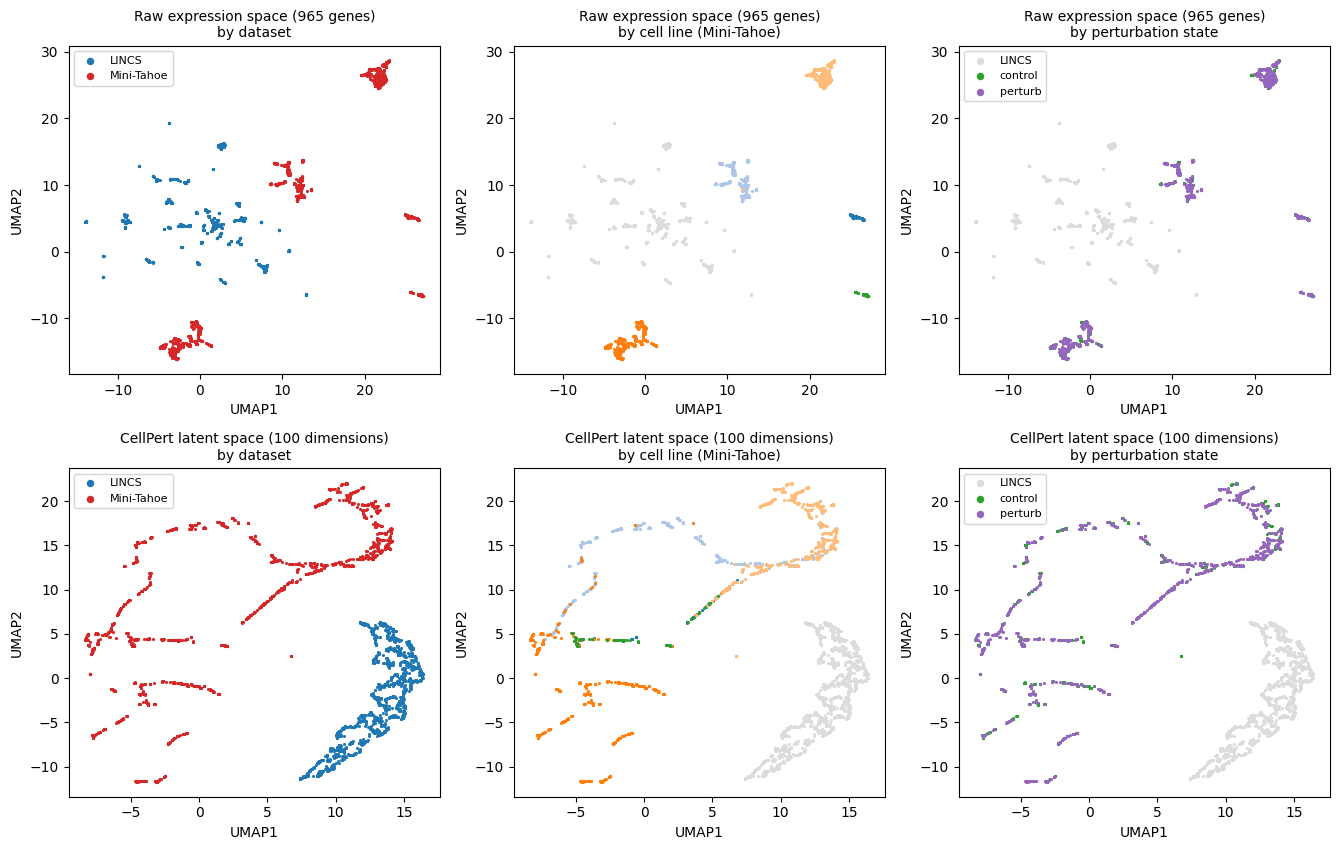

In [10]:
import umap
import matplotlib.pyplot as plt

# One plate is enough for the picture; the published version pools all fourteen.
TX, tobs = sample(tahoe_path, 2000, 1)
TZ = encode(TX)
cell_line = tobs['cell_type'].astype(str).values
condition = tobs['condition'].astype(str).values
dataset_lab = np.array(['LINCS'] * len(LX) + ['Mini-Tahoe'] * len(TX))

emb = {}
for space, (A, B) in (('raw', (LX, TX)), ('latent', (LZ, TZ))):
    emb[space] = umap.UMAP(n_neighbors=15, min_dist=0.1,
                           random_state=0).fit_transform(np.concatenate([A, B]))

GREY = '#DCDCDC'
n_l = len(LX)
lines = sorted(set(cell_line))
line_color = {c: plt.get_cmap('tab20')(i % 20) for i, c in enumerate(lines)}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))
for row, space in enumerate(('raw', 'latent')):
    E = emb[space]
    title = ('Raw expression space (965 genes)' if space == 'raw'
             else 'CellPert latent space (100 dimensions)')

    ax = axes[row, 0]
    for k, c in (('LINCS', '#1F77B4'), ('Mini-Tahoe', '#D62728')):
        m = dataset_lab == k
        ax.scatter(E[m, 0], E[m, 1], s=5, c=c, linewidths=0, label=k)
    ax.legend(fontsize=8, markerscale=2.4, frameon=True)
    ax.set_title(title + '\nby dataset', fontsize=10)

    ax = axes[row, 1]
    ax.scatter(E[:n_l, 0], E[:n_l, 1], s=5, c=GREY, linewidths=0, zorder=1)
    for c in lines:
        m = np.zeros(len(E), bool); m[n_l:] = cell_line == c
        ax.scatter(E[m, 0], E[m, 1], s=5, color=line_color[c], linewidths=0, zorder=2)
    ax.set_title(title + '\nby cell line (Mini-Tahoe)', fontsize=10)

    ax = axes[row, 2]
    ax.scatter(E[:n_l, 0], E[:n_l, 1], s=5, c=GREY, linewidths=0, label='LINCS', zorder=1)
    for k, c in (('control', '#2CA02C'), ('perturb', '#9467BD')):
        m = np.zeros(len(E), bool); m[n_l:] = condition == k
        ax.scatter(E[m, 0], E[m, 1], s=5, c=c, linewidths=0, label=k, zorder=2)
    ax.legend(fontsize=8, markerscale=2.4, frameon=True)
    ax.set_title(title + '\nby perturbation state', fontsize=10)

for ax in axes.ravel():
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
plt.tight_layout(); plt.show()
